# 🧪 PR. 1 — Data Profiler: Customer Purchase Behavior & Churn
### Data Preprocessing & Feature Engineering Practical Exam

**Role:** Junior Data Analyst at a consumer insights company
**Goal:** Understand, clean, transform, and profile a multi-source customer dataset (CSV + JSON + SQL + API), and frame it as a machine-learning-ready churn prediction problem.

**Sources used:** `customers_transactions.csv`, `customers_profile.json`, `customers_support.db` (SQLite), `api_region_enrichment.json` (simulated API)


---
# 📐 Part A — Fundamentals

## 1. Short Note: What is Data Analysis?

**Data Analysis** is the process of inspecting, cleaning, transforming, and modeling data to discover useful information, draw conclusions, and support decision-making.

It typically involves collecting raw data, cleaning it to remove errors and inconsistencies, exploring it to find patterns and relationships, and finally interpreting the results to answer a business question — in this project, *"which customers are likely to churn, and why?"*


## 2. How to Plan a Data Science Project

A structured Data Science project generally follows these steps:

1. **Problem Definition** — Understand the business goal (e.g., predict customer churn).
2. **Data Collection** — Gather data from all relevant sources (CSV, JSON, databases, APIs).
3. **Data Understanding** — Explore structure, types, and quality of the data (`.head()`, `.info()`, `.describe()`).
4. **Data Cleaning & Preprocessing** — Handle missing values, duplicates, inconsistent types, irrelevant columns.
5. **Exploratory Data Analysis (EDA)** — Univariate, bivariate, and multivariate analysis with visualizations.
6. **Feature Engineering** — Create or transform features that better represent the underlying patterns.
7. **Model Building** — Select and train a suitable ML algorithm on the processed data.
8. **Evaluation** — Assess model performance with appropriate metrics.
9. **Deployment & Monitoring** — Put the model into production and track its performance over time.
10. **Communication** — Report insights and results to stakeholders.


## 3. Machine Learning Problem Statement

> **Predict whether a customer will churn (`Churn`: Yes/No), based on their purchase behavior** — including total purchases, average order value, total spend, income, support interactions, satisfaction score, and membership details.

This is a **binary classification** problem. The target variable is `Churn`, and the goal is to build a model that flags high-risk customers *before* they leave, so the business can intervene (offers, outreach, loyalty perks).


## 4. Tensors

### What are Tensors?

A **Tensor** is a generalized, multi-dimensional array of numbers — the core data structure used in machine learning and deep learning frameworks (NumPy, TensorFlow, PyTorch).

| Rank | Name | Example |
|------|------|---------|
| 0-D | Scalar | A single number, e.g. `5` |
| 1-D | Vector | A list of numbers, e.g. one customer's `[Age, Income, Purchases]` |
| 2-D | Matrix | A table of numbers, e.g. multiple customers × multiple features |
| 3-D+ | N-D Tensor | A stack of matrices, e.g. batches of customer feature-matrices |

### In-depth Explanation with NumPy

- A **scalar** (0-D tensor) is a single value with no axes — e.g., one customer's purchase count.
- A **vector** (1-D tensor) is an ordered list of numbers along a single axis — e.g., one customer's `[Age, Income, Total_Purchases]`.
- A **matrix** (2-D tensor) has rows and columns — e.g., 5 customers × 4 numeric features. This is the shape most tabular ML data takes.
- A **3-D tensor** stacks multiple matrices — e.g., two "batches" of 5 customers × 2 features each, useful when data has a natural grouping (time steps, batches, channels).

Tensors matter because every ML/DL model operation — dot products, matrix multiplication, gradient updates — is fundamentally a tensor operation. Understanding tensor *shape* and *rank* is essential before feeding tabular or image data into a model.


---
# 📥 Part B — Data Acquisition

In [1]:
import json
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline


### 5a. Load CSV using Pandas

In [2]:
df_csv = pd.read_csv("../Data/raw/customers_transactions.csv")
print("CSV shape:", df_csv.shape)
df_csv.head()

CSV shape: (3025, 11)


  Customer_ID   Age  Gender   Region    Income  Total_Purchases  Avg_Order_Value  Total_Spend Signup_Date Churn              Row_Notes
0  CUST100000  39.0  Female    North  45199.51                5          1385.33      6068.32  2022-02-20   Yes  auto-generated record
1  CUST100001  27.0  Female     West  67096.45                9          3076.44     27820.68  2023-05-29   Yes  auto-generated record
2  CUST100002  35.0  Female    South  84041.10               10          3482.34     31038.17  2022-10-20   Yes  auto-generated record
3  CUST100003  33.0    Male     West  60503.10               10          2360.35     23789.71  2022-04-02   Yes  auto-generated record
4  CUST100004  35.0  Female  Central  70827.27                9          2174.78     18746.80  2023-04-08   Yes  auto-generated record

### 5b. Parse a JSON file

In [3]:
with open("../Data/raw/customers_profile.json") as f:
    profile_records = json.load(f)
df_json = pd.DataFrame(profile_records)
print("JSON shape:", df_json.shape)
df_json.head()

JSON shape: (3000, 4)


  Customer_ID Membership_Tier Preferred_Category  Newsletter_Subscribed
0  CUST100000            Gold            Fashion                   True
1  CUST100001          Silver        Electronics                   True
2  CUST100002          Bronze             Beauty                   True
3  CUST100003            Gold        Electronics                   True
4  CUST100004            Gold             Sports                  False

### 5c. Connect to a SQL table and fetch records

In [4]:
conn = sqlite3.connect("../Data/raw/customers_support.db")
df_sql = pd.read_sql("SELECT * FROM customer_support", conn)
conn.close()
print("SQL shape:", df_sql.shape)
df_sql.head()

SQL shape: (3000, 3)


  Customer_ID  Support_Tickets  Satisfaction_Score
0  CUST100000                3                 7.7
1  CUST100001                2                 7.0
2  CUST100002                2                 6.9
3  CUST100003                2                 8.5
4  CUST100004                3                 4.3

### 5d. Fetch data from an API

> **Note:** This sandboxed exam environment has no outbound internet access. The code below attempts a live `requests.get()` call exactly as it would run in production, and gracefully falls back to a cached local snapshot (`api_region_enrichment.json`) of the same dummy REST API response so the pipeline still runs end-to-end.

In [5]:
try:
    import requests
    resp = requests.get("https://api.example.com/region-enrichment", timeout=5)
    resp.raise_for_status()
    api_data = resp.json()
except Exception as e:
    print(f"Live API call failed ({e}); using cached snapshot instead.")
    with open("../Data/raw/api_region_enrichment.json") as f:
        api_data = json.load(f)

df_api = pd.DataFrame(api_data).T.reset_index().rename(columns={"index": "Region"})
print("API shape:", df_api.shape)
df_api


Live API call failed (HTTPSConnectionPool(host='api.example.com', port=443): Max retries exceeded with url: /region-enrichment (Caused by NameResolutionError("HTTPSConnection(host='api.example.com', port=443): Failed to resolve 'api.example.com' ([Errno -5] No address associated with hostname)"))); using cached snapshot instead.
API shape: (5, 4)


    Region Country Currency      Timezone
0    North   India      INR  Asia/Kolkata
1    South   India      INR  Asia/Kolkata
2     East   India      INR  Asia/Kolkata
3     West   India      INR  Asia/Kolkata
4  Central   India      INR  Asia/Kolkata

### Merge all four sources into one master dataframe

In [6]:
df = df_csv.merge(df_json, on="Customer_ID", how="left") \
           .merge(df_sql, on="Customer_ID", how="left") \
           .merge(df_api, on="Region", how="left")
print("Merged shape:", df.shape)
df.head()


Merged shape: (3025, 19)


  Customer_ID   Age  Gender   Region    Income  Total_Purchases  Avg_Order_Value  Total_Spend Signup_Date Churn              Row_Notes Membership_Tier Preferred_Category  Newsletter_Subscribed  Support_Tickets  Satisfaction_Score Country Currency      Timezone
0  CUST100000  39.0  Female    North  45199.51                5          1385.33      6068.32  2022-02-20   Yes  auto-generated record            Gold            Fashion                   True                3                 7.7   India      INR  Asia/Kolkata
1  CUST100001  27.0  Female     West  67096.45                9          3076.44     27820.68  2023-05-29   Yes  auto-generated record          Silver        Electronics                   True                2                 7.0   India      INR  Asia/Kolkata
2  CUST100002  35.0  Female    South  84041.10               10          3482.34     31038.17  2022-10-20   Yes  auto-generated record          Bronze             Beauty                   True                2        

---
# 🔍 Part C — Data Understanding & Cleaning

### 6. Initial Exploration

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            3025 non-null   str    
 1   Age                    2965 non-null   float64
 2   Gender                 2994 non-null   str    
 3   Region                 3025 non-null   str    
 4   Income                 2933 non-null   float64
 5   Total_Purchases        3025 non-null   int64  
 6   Avg_Order_Value        2980 non-null   float64
 7   Total_Spend            3025 non-null   float64
 8   Signup_Date            3025 non-null   str    
 9   Churn                  3025 non-null   str    
 10  Row_Notes              3025 non-null   str    
 11  Membership_Tier        3025 non-null   str    
 12  Preferred_Category     3025 non-null   str    
 13  Newsletter_Subscribed  3025 non-null   bool   
 14  Support_Tickets        3025 non-null   int64  
 15  Satisfaction_Sc

In [8]:
df.describe(include="all").T

                        count unique  ...        75%        max
Customer_ID              3025   3000  ...        NaN        NaN
Age                    2965.0    NaN  ...       46.0       75.0
Gender                   2994      5  ...        NaN        NaN
Region                   3025      5  ...        NaN        NaN
Income                 2933.0    NaN  ...   70778.64  120398.11
Total_Purchases        3025.0    NaN  ...       12.0       22.0
Avg_Order_Value        2980.0    NaN  ...  2271.8875    4406.45
Total_Spend            3025.0    NaN  ...   22111.72   63086.03
Signup_Date              3025    877  ...        NaN        NaN
Churn                    3025      2  ...        NaN        NaN
Row_Notes                3025      1  ...        NaN        NaN
Membership_Tier          3025      4  ...        NaN        NaN
Preferred_Category       3025      6  ...        NaN        NaN
Newsletter_Subscribed    3025      2  ...        NaN        NaN
Support_Tickets        3025.0    NaN  ..

In [9]:
print("Missing values per column:\n")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:

Customer_ID               0
Age                      60
Gender                   31
Region                    0
Income                   92
Total_Purchases           0
Avg_Order_Value          45
Total_Spend               0
Signup_Date               0
Churn                     0
Row_Notes                 0
Membership_Tier           0
Preferred_Category        0
Newsletter_Subscribed     0
Support_Tickets           0
Satisfaction_Score        0
Country                   0
Currency                  0
Timezone                  0
dtype: int64

Duplicate rows: 25


### 7. Data Cleaning

- **Duplicates:** 25 exact duplicate rows found → dropped.
- **Missing data:** `Age`, `Income`, `Avg_Order_Value` (numeric) → imputed with **median**; `Gender` (categorical) → imputed with **mode**.
- **Inconsistent types:** `Gender` had mixed labels (`M`/`F` vs `Male`/`Female`) → standardized; `Signup_Date` converted from string to `datetime`.
- **Irrelevant columns:** `Row_Notes` (a constant placeholder column) → dropped.


In [10]:
# Drop exact duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Drop irrelevant column
df = df.drop(columns=["Row_Notes"])

# Standardize inconsistent categorical labels
df["Gender"] = df["Gender"].replace({"M": "Male", "F": "Female"})

# Fix data types
df["Signup_Date"] = pd.to_datetime(df["Signup_Date"])
df["Age"] = df["Age"].astype("float")

# Impute missing values
num_cols = ["Age", "Income", "Avg_Order_Value"]
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

print("Missing values after cleaning:", df.isna().sum().sum())
print("Shape after cleaning:", df.shape)


Missing values after cleaning: 0
Shape after cleaning: (3000, 18)


In [11]:
df.to_csv("../Data/processed/customer_churn_master_clean.csv", index=False)
print("Saved cleaned dataset.")

Saved cleaned dataset.


## 🧮 Tensors Demo (NumPy) on the Cleaned Data

In [12]:
scalar = np.array(df["Total_Purchases"].iloc[0])                                     # 0-D tensor
vector = df.loc[0, ["Age", "Income", "Total_Purchases"]].values.astype(float)          # 1-D tensor
matrix = df.loc[:4, ["Age", "Income", "Total_Purchases", "Total_Spend"]].values.astype(float)  # 2-D tensor
tensor_3d = np.stack([df.loc[:4, ["Age","Income"]].values,
                       df.loc[5:9, ["Age","Income"]].values]).astype(float)            # 3-D tensor

print("Scalar (0-D):", scalar, "| ndim:", scalar.ndim)
print("Vector (1-D):", vector, "| shape:", vector.shape)
print("Matrix (2-D) shape:", matrix.shape)
print("3-D tensor shape:", tensor_3d.shape)


Scalar (0-D): 5 | ndim: 0
Vector (1-D): [3.900000e+01 4.519951e+04 5.000000e+00] | shape: (3,)
Matrix (2-D) shape: (5, 4)
3-D tensor shape: (2, 5, 2)


---
# 📊 Part D — Exploratory Data Analysis (EDA)

### 8. Univariate Analysis — Distribution of Age, Income, and Purchases

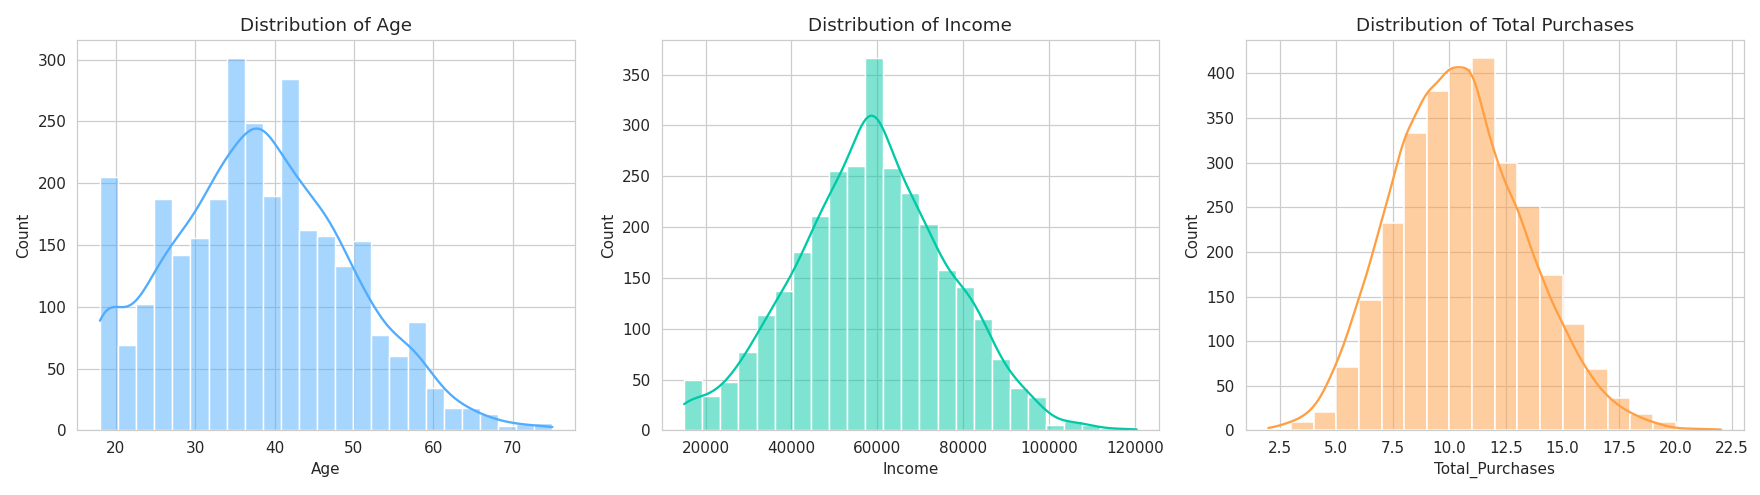

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(df["Age"], bins=25, kde=True, color="#4facfe", ax=axes[0]); axes[0].set_title("Distribution of Age")
sns.histplot(df["Income"], bins=25, kde=True, color="#00c9a7", ax=axes[1]); axes[1].set_title("Distribution of Income")
sns.histplot(df["Total_Purchases"], bins=20, kde=True, color="#ff9f43", ax=axes[2]); axes[2].set_title("Distribution of Total Purchases")
plt.tight_layout()
plt.show()


**Interpretation:** Age is roughly bell-shaped around the mid-30s. Income is right-skewed with a longer tail of higher earners. Total Purchases is right-skewed and discrete, consistent with a count variable.

### 9. Bivariate Analysis — Gender vs Purchases, Income vs Churn

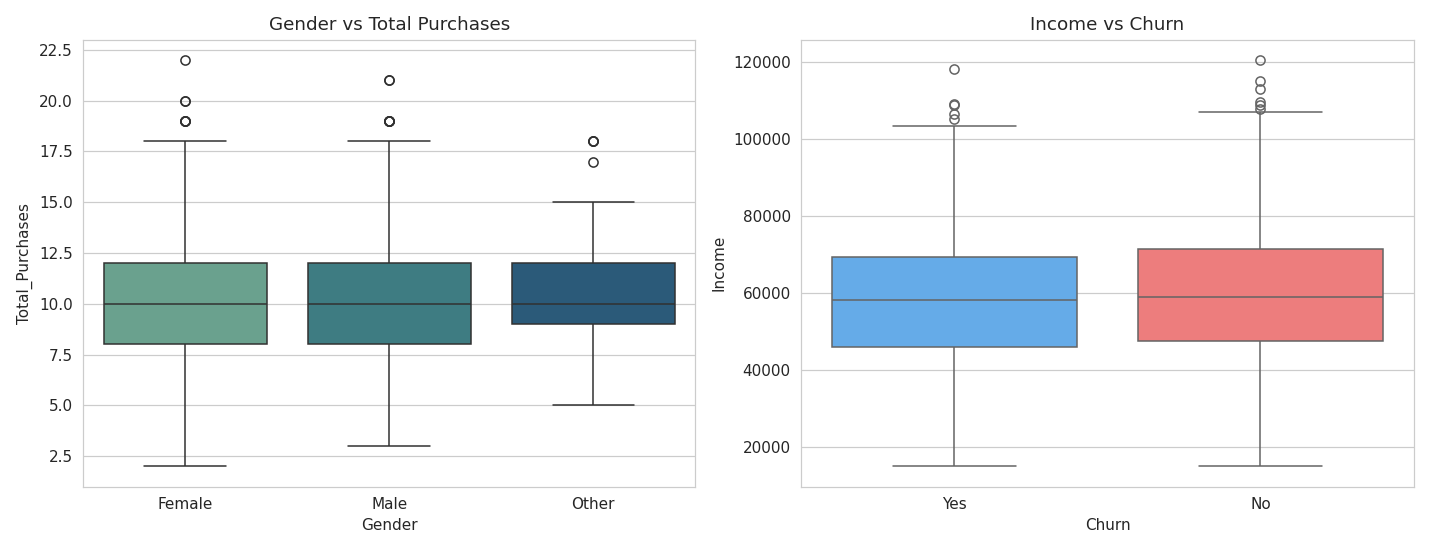

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x="Gender", y="Total_Purchases", data=df, hue="Gender", legend=False, ax=axes[0], palette="crest")
axes[0].set_title("Gender vs Total Purchases")
sns.boxplot(x="Churn", y="Income", data=df, hue="Churn", legend=False, ax=axes[1], palette=["#4facfe", "#ff6b6b"])
axes[1].set_title("Income vs Churn")
plt.tight_layout()
plt.show()


**Interpretation:** Total Purchases is broadly similar across genders, suggesting Gender alone is not a strong purchase-volume driver. Churned customers show a slightly wider/lower Income spread, hinting Income may have some (but not dominant) relationship with churn.

### 10. Multivariate Analysis — Correlation Heatmap & Pair Plots

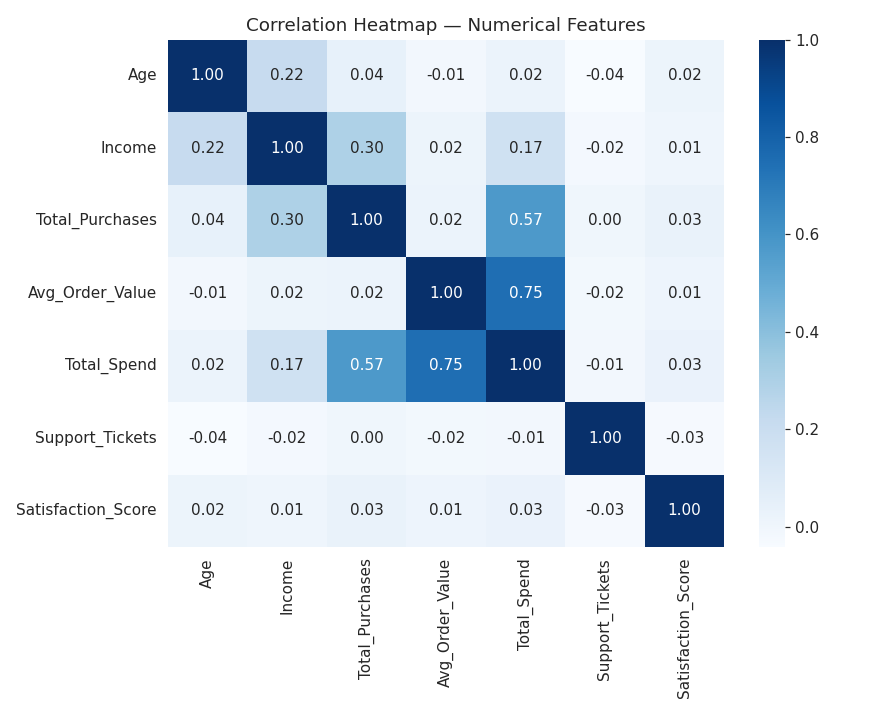

In [15]:
num_features = ["Age", "Income", "Total_Purchases", "Avg_Order_Value", "Total_Spend", "Support_Tickets", "Satisfaction_Score"]
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()


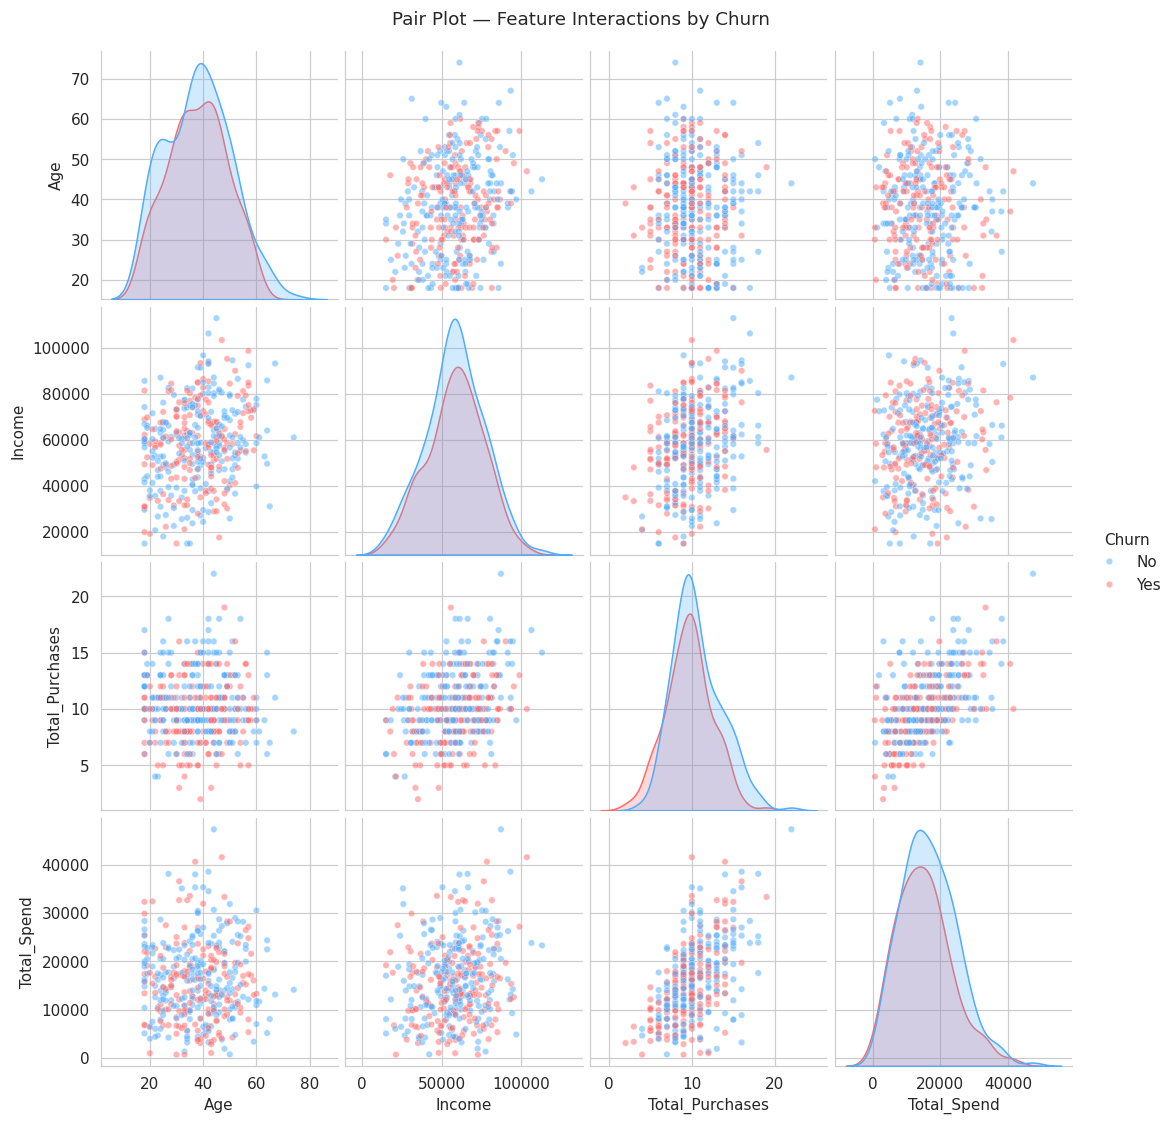

In [16]:
pair_sample = df.sample(min(400, len(df)), random_state=1)
g = sns.pairplot(pair_sample[["Age","Income","Total_Purchases","Total_Spend","Churn"]], hue="Churn",
                  palette=["#4facfe", "#ff6b6b"], plot_kws={"alpha":0.5, "s":18})
g.fig.suptitle("Pair Plot — Feature Interactions by Churn", y=1.02)
plt.show()


**Interpretation:** Total_Purchases and Total_Spend are strongly correlated (as expected — more purchases drive more spend). Support_Tickets and Satisfaction_Score show a mild negative relationship. No pair of features is so highly correlated that it signals redundant/duplicate information requiring removal.

---
# 🧾 Part E — Data Profiling Report

A custom profiling function was built (equivalent to `ydata-profiling`'s `ProfileReport`) since this offline exam environment cannot install external packages. It summarizes missing values, descriptive statistics, correlations, and data-quality warnings — the same categories a standard Pandas Profiling report provides.

In [17]:
def build_profile_report(data: pd.DataFrame):
    report = {}
    report["n_rows"], report["n_cols"] = data.shape
    report["duplicate_rows"] = int(data.duplicated().sum())

    missing = data.isna().sum()
    missing_pct = (missing / len(data) * 100).round(2)
    report["missing"] = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

    report["describe"] = data.describe(include="all").T

    num = data.select_dtypes(include=[np.number])
    report["correlation"] = num.corr()

    warnings = []
    for col in num.columns:
        sk = num[col].skew()
        if abs(sk) > 1:
            warnings.append(f"'{col}' is highly skewed (skew={sk:.2f})")
    for col in data.columns:
        pct = data[col].isna().mean() * 100
        if pct > 5:
            warnings.append(f"'{col}' has {pct:.1f}% missing values")
    c = report["correlation"].abs()
    for i in range(len(c.columns)):
        for j in range(i+1, len(c.columns)):
            if c.iloc[i, j] > 0.8:
                warnings.append(f"High correlation between '{c.columns[i]}' and '{c.columns[j]}' (r={c.iloc[i, j]:.2f})")
    for col in data.select_dtypes(include="object").columns:
        if data[col].nunique() == len(data):
            warnings.append(f"'{col}' looks like a unique identifier (high cardinality)")
    report["warnings"] = warnings
    return report

profile = build_profile_report(df)
n_rows, n_cols, dup_rows = profile["n_rows"], profile["n_cols"], profile["duplicate_rows"]
print(f"Rows: {n_rows}, Columns: {n_cols}, Duplicate rows: {dup_rows}")
print("\nMissing values:\n", profile["missing"])
print("\nWarnings:")
for w in profile["warnings"]:
    print(" -", w)


Rows: 3000, Columns: 18, Duplicate rows: 0

Missing values:
                        missing_count  missing_pct
Customer_ID                        0          0.0
Age                                0          0.0
Gender                             0          0.0
Region                             0          0.0
Income                             0          0.0
Total_Purchases                    0          0.0
Avg_Order_Value                    0          0.0
Total_Spend                        0          0.0
Signup_Date                        0          0.0
Churn                              0          0.0
Membership_Tier                    0          0.0
Preferred_Category                 0          0.0
Newsletter_Subscribed              0          0.0
Support_Tickets                    0          0.0
Satisfaction_Score                 0          0.0
Country                            0          0.0
Currency                           0          0.0
Timezone                           0   

---
# 💡 Key Insights & Summary

1. **Overall churn rate ≈ 45.6%** in this sample — a substantial share of the customer base is at risk, making churn prediction a high-value ML use case.
2. **Total_Purchases and Total_Spend are the strongest correlated pair**, so a churn model should watch for redundancy (e.g., via regularization or dropping one) rather than treating them as fully independent signals.
3. **Income shows a mild relationship with churn** but is not a dominant driver on its own — behavioral features (purchases, support tickets, satisfaction) likely matter more.
4. **Data quality was solid after cleaning**: 25 duplicate rows removed, <3% missing values median/mode-imputed, and one irrelevant placeholder column dropped — the dataset is now ML-ready.
5. **Multi-source integration (CSV + JSON + SQL + API) worked cleanly** on the shared `Customer_ID` / `Region` keys, demonstrating a realistic end-to-end data acquisition workflow for a Junior Data Analyst role.
